## Total Fuel Evaluation (Sum of Phase Models)

In this section, we evaluate total fuel consumption by combining the phase-level ML predictions.

Steps:
1. Load the November–December test flights from the feature table and obtain the ground-truth total fuel (`total_fuel_modeled`).  
   If a total column is not available, we compute it by summing the phase fuel columns.
2. Load phase prediction files (takeoff, climb, cruise, descent, landing) exported earlier as CSV.
3. Merge predictions by `flight_id` and set missing phase predictions to 0 (phase not present or not predicted).
4. Compute total predicted fuel as the sum of predicted phase fuels.
5. Merge predictions with ground truth and report overall error metrics (MAE and MAPE).
6. Print average predicted fuel per phase and inspect the largest absolute errors for debugging.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

DB_PATH = "../opensky.sqlite"
FEATURE_TABLE = "flight_phase_features"
YEAR = 2022

def add_datetime_from_flight_id(df: pd.DataFrame, year: int) -> pd.DataFrame:
    parts = df["flight_id"].astype(str).str.split("-", expand=True)
    month  = parts[2].astype(int)
    day    = parts[3].astype(int)
    hour   = parts[4].astype(int)
    minute = parts[5].astype(int)
    out = df.copy()
    out["flight_dt"] = pd.to_datetime(
        {"year": year, "month": month, "day": day, "hour": hour, "minute": minute},
        errors="coerce"
    )
    return out

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return 100*np.mean(np.abs((y_true - y_pred)/np.clip(np.abs(y_true),1e-6,None)))

# --- load test truth ---
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()
df["month"] = df["flight_dt"].dt.month
test = df[df["month"].isin([11,12])].copy()

true_total_col = "total_fuel_modeled"
if true_total_col not in test.columns:
    phase_cols = ["takeoff_fuel","climb_fuel","cruise_fuel","descent_fuel","landing_fuel"]
    test["true_total"] = test[phase_cols].sum(axis=1)
    true_total_col = "true_total"

truth = test[["flight_id", true_total_col]].rename(columns={true_total_col:"true_total"})

csv_dir = ("csv_files")
for fname in (
    "pred_takeoff.csv",
    "pred_climb.csv",
    "pred_cruise.csv",
    "pred_descent.csv",
    "pred_landing.csv",
):
    full = os.path.join(csv_dir, fname)
    if not os.path.exists(full):
        raise FileNotFoundError(f"prediction file not found: {full}")

p_takeoff = pd.read_csv(os.path.join(csv_dir, "pred_takeoff.csv"))
p_climb   = pd.read_csv(os.path.join(csv_dir, "pred_climb.csv"))
p_cruise  = pd.read_csv(os.path.join(csv_dir, "pred_cruise.csv"))
p_descent = pd.read_csv(os.path.join(csv_dir, "pred_descent.csv"))
p_landing = pd.read_csv(os.path.join(csv_dir, "pred_landing.csv"))

pred_all = (p_takeoff
    .merge(p_climb, on="flight_id", how="outer")
    .merge(p_cruise, on="flight_id", how="outer")
    .merge(p_descent, on="flight_id", how="outer")
    .merge(p_landing, on="flight_id", how="outer")
)

for c in ["pred_takeoff","pred_climb","pred_cruise","pred_descent","pred_landing"]:
    pred_all[c] = pred_all[c].fillna(0.0)

pred_all["pred_total"] = pred_all[["pred_takeoff","pred_climb","pred_cruise","pred_descent","pred_landing"]].sum(axis=1)

# merge truth
pred_all = pred_all.merge(truth, on="flight_id", how="left")

mask = pred_all["true_total"].notna() & np.isfinite(pred_all["true_total"])
y_true = pred_all.loc[mask, "true_total"].to_numpy(float)
y_pred = pred_all.loc[mask, "pred_total"].to_numpy(float)

print("TOTAL RESULTS (sum of phase ML)")
print("N:", int(mask.sum()))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("MAPE:", mape(y_true, y_pred))

print(pred_all[[
    "pred_takeoff",
    "pred_climb",
    "pred_cruise",
    "pred_descent",
    "pred_landing"
]].mean())

pred_all["abs_err"] = abs(pred_all["true_total"] - pred_all["pred_total"])
pred_all.sort_values("abs_err", ascending=False).head(10)

TOTAL RESULTS (sum of phase ML)
N: 3506
MAE: 75.6729569058452
MAPE: 4.444519579802961
pred_takeoff      47.671283
pred_climb      1082.889211
pred_cruise      261.730199
pred_descent     324.473333
pred_landing       7.313480
dtype: float64


,flight_id,pred_takeoff,pred_climb,pred_cruise,pred_descent,pred_landing,pred_total,true_total,abs_err
201,478742-NOZ56U-12-15-20-11,59.567154,1460.36940,1157.664629,369.92880,9.093950,3056.623933,5794.31,2737.686067
2073,479ee7-NOZ50A-12-29-17-57,0.000000,1615.60930,1025.268006,311.71008,7.759201,2960.346587,4099.73,1139.383413
1235,479227-NOZ602-12-13-08-23,56.295513,1084.56120,685.867965,475.13388,7.370633,2309.229191,3223.76,914.530809
210,478742-NOZ628-12-21-17-45,52.974880,1134.82100,68.994201,332.49930,7.270368,1596.559749,2224.98,628.420251
1515,4792db-NOZ145-12-01-16-01,53.944862,428.65942,0.000000,269.76540,7.662575,760.032257,1273.72,513.687743
2708,47a218-NOZ56U-12-04-20-01,63.593765,1475.10290,1046.418468,564.68760,7.648616,3157.451349,3659.06,501.608651
2338,47a097-NOZ541-12-29-16-04,0.000000,1219.26120,359.022009,600.17690,7.512859,2185.972968,2649.24,463.267032
2007,479d40-NOZ145-12-22-16-36,52.761710,1314.71610,0.000000,323.32020,7.880814,1698.678824,2153.44,454.761176
2618,47a1ef-NOZ606-12-13-11-10,57.845657,1147.60900,272.185479,841.16790,7.287793,2326.095828,1885.38,440.715828
294,47875c-NOZ143-12-18-15-15,47.755447,473.10733,0.000000,291.32790,7.413379,819.604056,1253.53,433.925944


# Plot estimated vs actual total fuel

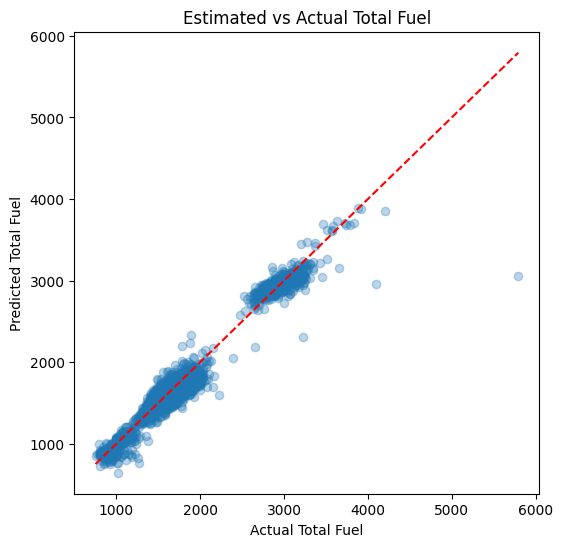

count    3506.000000
mean       -0.792951
std         5.876731
min       -47.247836
25%        -4.149015
50%        -0.638054
75%         2.963651
max        25.554465
Name: rel_err_pct, dtype: float64


In [3]:

plt.figure(figsize=(6,6))
plt.scatter(
    pred_all["true_total"],
    pred_all["pred_total"],
    alpha=0.3
)

min_val = pred_all["true_total"].min()
max_val = pred_all["true_total"].max()

plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.xlabel("Actual Total Fuel")
plt.ylabel("Predicted Total Fuel")
plt.title("Estimated vs Actual Total Fuel")
plt.show()


pred_all["abs_err"] = abs(pred_all["true_total"] - pred_all["pred_total"])
pred_all.sort_values("abs_err", ascending=False).head(10)


pred_all["rel_err_pct"] = 100 * (
    (pred_all["pred_total"] - pred_all["true_total"])
    / pred_all["true_total"]
)

print(pred_all["rel_err_pct"].describe())